In [48]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.utils import resample

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Activation,
    Conv2D,
    MaxPooling2D,
    Dense,
    Dropout,
    Flatten,
    GlobalAveragePooling2D,
    BatchNormalization,
    Input
)

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [49]:
IMG_SIZE = 224
BATCH_SIZE = 64
NUM_CLASSES = 3

MODEL_DIR = "../cv_models"
os.makedirs(MODEL_DIR, exist_ok=True)

In [50]:
train_df = pd.read_csv("../data/cv_train.csv")
test_df = pd.read_csv("../data/cv_test.csv")

imgs1 = os.listdir("../data/HAM10000_images_part_1/")
imgs2 = os.listdir("../data/HAM10000_images_part_2/")

print("Part 1 sample:", imgs1[:5])
print("Part 2 sample:", imgs2[:5])

Part 1 sample: ['ISIC_0024306.jpg', 'ISIC_0024307.jpg', 'ISIC_0024308.jpg', 'ISIC_0024309.jpg', 'ISIC_0024310.jpg']
Part 2 sample: ['ISIC_0029306.jpg', 'ISIC_0029307.jpg', 'ISIC_0029308.jpg', 'ISIC_0029309.jpg', 'ISIC_0029310.jpg']


In [51]:
csv_ids = set(train_df["image_id"])
img_ids = set([os.path.splitext(f)[0] for f in os.listdir("../data/HAM10000_images_part_1")] +
              [os.path.splitext(f)[0] for f in os.listdir("../data/HAM10000_images_part_2")])

print("Overlap:", len(csv_ids & img_ids))

Overlap: 8020


In [52]:
import os

IMAGE_DIRS = [
    r"..\data\HAM10000_images_part_1",
   r"..\data\HAM10000_images_part_2"
]

image_path_dict = {}

for folder in IMAGE_DIRS:
    for img in os.listdir(folder):
        if img.endswith(".jpg"):
            image_id = os.path.splitext(img)[0]
            image_path_dict[image_id] = os.path.join(folder, img)
            
train_df["image_path"] = train_df["image_id"].map(image_path_dict)
test_df["image_path"] = test_df["image_id"].map(image_path_dict)


print("LOADED")
print("Missing train images:", train_df["image_path"].isna().sum())
print("Missing test images:", test_df["image_path"].isna().sum())

LOADED
Missing train images: 0
Missing test images: 0


In [53]:
print(train_df.head())

       image_id   dx                                       image_path
0  ISIC_0026769  bkl  ..\data\HAM10000_images_part_1\ISIC_0026769.jpg
1  ISIC_0025661  bkl  ..\data\HAM10000_images_part_1\ISIC_0025661.jpg
2  ISIC_0031633  bkl  ..\data\HAM10000_images_part_2\ISIC_0031633.jpg
3  ISIC_0027850  bkl  ..\data\HAM10000_images_part_1\ISIC_0027850.jpg
4  ISIC_0029176  bkl  ..\data\HAM10000_images_part_1\ISIC_0029176.jpg


In [54]:
print("Original Classes")
print(train_df["dx"].value_counts())

Original Classes
dx
nv       5368
mel       895
bkl       881
bcc       414
akiec     265
vasc      110
df         87
Name: count, dtype: int64


In [55]:
urgency_map = {
    "nv": "low",
    "bkl": "low",
    "df": "low",
    "vasc": "low",

    "bcc": "medium",
    "akiec": "medium",

    "mel": "high"
}

In [56]:
train_df["urgency"] = train_df["dx"].map(urgency_map)
test_df["urgency"] = test_df["dx"].map(urgency_map)

In [57]:
print("\nUrgency Classes")
print(train_df["urgency"].value_counts())


Urgency Classes
urgency
low       6446
high       895
medium     679
Name: count, dtype: int64


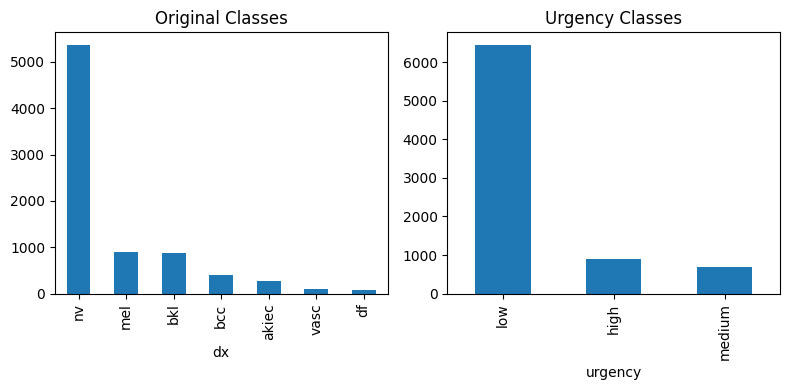

In [58]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
train_df["dx"].value_counts().plot(kind="bar")
plt.title("Original Classes")

plt.subplot(1,2,2)
train_df["urgency"].value_counts().plot(kind="bar")
plt.title("Urgency Classes")

plt.tight_layout()
plt.show()

In [59]:
train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["urgency"],
    random_state=42
)

In [ ]:
from sklearn.utils import resample

target_size = 2500

balanced = []

for cls in ["high", "medium"]:

    cls_df = train_df[train_df["urgency"] == cls]

    upsampled = resample(
        cls_df,
        replace=True,
        n_samples=target_size,
        random_state=42
    )

    balanced.append(upsampled)

low_df = train_df[train_df["urgency"] == "low"]

balanced.append(low_df)

train_df_balanced = pd.concat(balanced)

train_df_balanced = train_df_balanced.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)


In [72]:
print(train_df_balanced["urgency"].value_counts())

urgency
low       5157
medium    2500
high      2500
Name: count, dtype: int64


In [61]:
# Data Generators with some augmentation for training and validation
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=True
)

val_datagen = ImageDataGenerator()

test_datagen = ImageDataGenerator()

In [73]:
# Load Data
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df_balanced,
    x_col="image_path",
    y_col="urgency",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    seed=42
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="urgency",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False,
    seed=42
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="urgency",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 10157 validated image filenames belonging to 3 classes.
Found 1604 validated image filenames belonging to 3 classes.
Found 1995 validated image filenames belonging to 3 classes.


In [75]:
# Handle Class Imbalance
# def get_class_weights(train_df = train_df):
#     classes = np.unique(train_df['dx'])
#     weights = compute_class_weight('balanced', classes=classes, y=train_df['dx'])
#     class_weights = dict(zip(classes, weights))
#     return class_weights
ordered_classes = list(train_generator.class_indices.keys())

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array(ordered_classes),
    y=train_df_balanced["urgency"]
)

class_weights_dict = {
    train_generator.class_indices[c]: w
    for c, w in zip(ordered_classes, weights)
}

print("Aligned Class Weights for Training:")
for cls, idx in train_generator.class_indices.items():
    print(f" Class {idx} ({cls}): Weight = {class_weights_dict[idx]:.4f}")

Aligned Class Weights for Training:
 Class 0 (high): Weight = 1.3543
 Class 1 (low): Weight = 0.6565
 Class 2 (medium): Weight = 1.3543


In [76]:
print(train_generator.class_indices)
print(val_generator.class_indices)


{'high': 0, 'low': 1, 'medium': 2}
{'high': 0, 'low': 1, 'medium': 2}


In [65]:
# Callbacks
def get_callbacks(model_name, model_dir=MODEL_DIR):
    """
    Creates training callbacks with automatic checkpoint path handling.
    """

    os.makedirs(model_dir, exist_ok=True)

    checkpoint_path = os.path.join(
        model_dir,
        f"{model_name}_best.keras"
    )

    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        ),

        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=3
        ),

        ModelCheckpoint(
            checkpoint_path,
            monitor='val_loss',
            save_best_only=True,
            verbose=1
        )
    ]

    return callbacks

In [66]:
def evaluate_model(model, model_name="Model"):

    test_generator.reset()

    preds = model.predict(test_generator)

    y_pred = np.argmax(preds, axis=1)
    y_true = test_generator.classes

    class_names = list(test_generator.class_indices.keys())

    print(f"\n{'='*70}")
    print(model_name.upper())
    print(f"{'='*70}")

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=class_names
        )
    )

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    print(f"Accuracy     : {accuracy:.4f}")
    print(f"Precision    : {precision:.4f}")
    print(f"Recall       : {recall:.4f}")
    print(f"Weighted F1  : {weighted_f1:.4f}")
    print(f"Macro F1     : {macro_f1:.4f}")

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Weighted_F1": weighted_f1,
        "Macro_F1": macro_f1
    }

In [67]:
def plot_training_history(history, model_name="Model"):

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(history.history["loss"])
    plt.plot(history.history["val_loss"])
    plt.title(f"{model_name} Loss")
    plt.legend(["Train","Val"])

    plt.subplot(1,2,2)
    plt.plot(history.history["accuracy"])
    plt.plot(history.history["val_accuracy"])
    plt.title(f"{model_name} Accuracy")
    plt.legend(["Train","Val"])

    plt.tight_layout()
    plt.show()

### MODEL 1 - EfficientNetB0 Frozen (BASELINE)

In [77]:
# Build Model
base_model = tf.keras.applications.EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

In [78]:
inputs = Input(shape=(224,224,3))

x = base_model(inputs)

x = GlobalAveragePooling2D()(x)

x = Dropout(0.3)(x)

outputs = Dense(
    3,
    activation='softmax'
)(x)

effb0_model = Model(
    inputs,
    outputs
)

In [79]:
# Compile
effb0_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [80]:
# Train
history_b0 = effb0_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights_dict,
    callbacks=get_callbacks("effb0")
)

Epoch 1/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5611 - loss: 0.9009
Epoch 1: val_loss improved from None to 0.67470, saving model to ../cv_models\effb0_best.keras
159/159 ━━━━━━━━━━━━━━━━━━━━ 738s 4s/step - accuracy: 0.6398 - loss: 0.7874 - val_accuracy: 0.7095 - val_loss: 0.6747 - learning_rate: 0.0010
Epoch 2/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7073 - loss: 0.6710
Epoch 2: val_loss did not improve from 0.67470
159/159 ━━━━━━━━━━━━━━━━━━━━ 671s 4s/step - accuracy: 0.7106 - loss: 0.6599 - val_accuracy: 0.6509 - val_loss: 0.7509 - learning_rate: 0.0010
Epoch 3/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7174 - loss: 0.6272
Epoch 3: val_loss improved from 0.67470 to 0.66935, saving model to ../cv_models\effb0_best.keras
159/159 ━━━━━━━━━━━━━━━━━━━━ 739s 5s/step - accuracy: 0.7210 - loss: 0.6220 - val_accuracy: 0.7020 - val_loss: 0.6694 - learning_rate: 0.0010
Epoch 4/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7263 - loss: 0

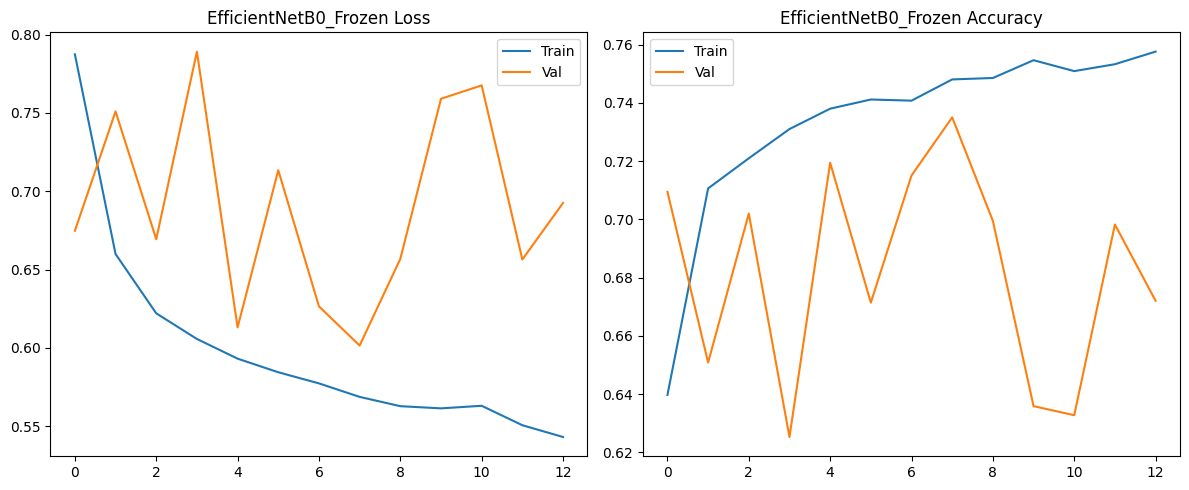

32/32 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step

EFFICIENTNETB0_FROZEN
              precision    recall  f1-score   support

        high       0.26      0.65      0.37       218
         low       0.95      0.70      0.81      1615
      medium       0.47      0.74      0.57       162

    accuracy                           0.70      1995
   macro avg       0.56      0.70      0.58      1995
weighted avg       0.83      0.70      0.74      1995

Accuracy     : 0.7013
Precision    : 0.8347
Recall       : 0.7013
Weighted F1  : 0.7419
Macro F1     : 0.5844


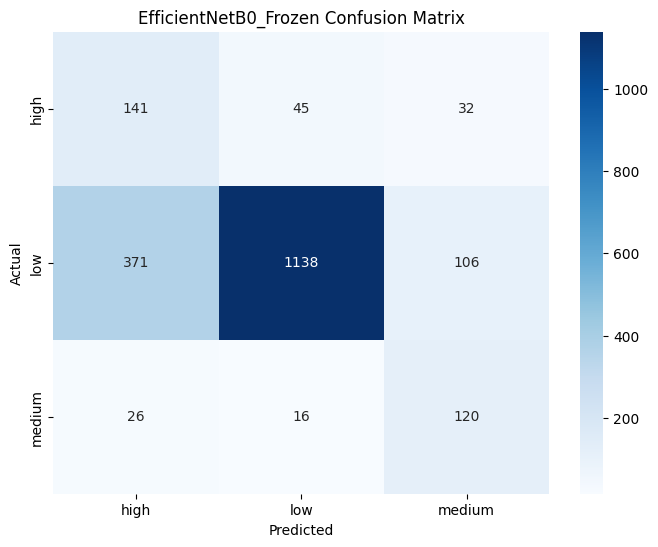

In [81]:
plot_training_history(
    history_b0,
    "EfficientNetB0_Frozen"
)

results = evaluate_model(
    effb0_model,
    "EfficientNetB0_Frozen"
)

In [82]:
effb0_model.save("../cv_models/effb0_frozen.keras")

In [86]:
print(history_b0.history["accuracy"])
print(history_b0.history["val_accuracy"])

print(history_b0.history["loss"])
print(history_b0.history["val_loss"])

[0.6397558450698853, 0.71064293384552, 0.7209805846214294, 0.7310229539871216, 0.7380132079124451, 0.7411637306213379, 0.7407699227333069, 0.7480555176734924, 0.7485477924346924, 0.7546519637107849, 0.7509106993675232, 0.753273606300354, 0.7576056122779846]
[0.7094762921333313, 0.6508728265762329, 0.7019950151443481, 0.6253117322921753, 0.719451367855072, 0.6714463829994202, 0.7150872945785522, 0.7350373864173889, 0.6995012760162354, 0.6359102129936218, 0.6327930092811584, 0.6982543468475342, 0.6720698475837708]
[0.7873920202255249, 0.6598867177963257, 0.6220337748527527, 0.6056675314903259, 0.5930957794189453, 0.5844182968139648, 0.5773153901100159, 0.5686908960342407, 0.5627567172050476, 0.5613721013069153, 0.5630084872245789, 0.5506030917167664, 0.5430814027786255]
[0.6746957302093506, 0.7509171962738037, 0.6693543195724487, 0.789107084274292, 0.6130885481834412, 0.7133932709693909, 0.6264678835868835, 0.6014624238014221, 0.6567916870117188, 0.759008526802063, 0.7675360441207886, 0.

### MODEL 2 - EfficientNetB0 Finetuned

In [87]:
base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False

In [88]:
effb0_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [89]:
history_b0_ft = effb0_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights_dict,
    callbacks=get_callbacks("effb0_finetuned")
)

Epoch 1/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7591 - loss: 0.5596
Epoch 1: val_loss improved from None to 0.64032, saving model to ../cv_models\effb0_finetuned_best.keras
159/159 ━━━━━━━━━━━━━━━━━━━━ 653s 4s/step - accuracy: 0.7578 - loss: 0.5640 - val_accuracy: 0.7101 - val_loss: 0.6403 - learning_rate: 1.0000e-05
Epoch 2/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7406 - loss: 0.5784
Epoch 2: val_loss did not improve from 0.64032
159/159 ━━━━━━━━━━━━━━━━━━━━ 584s 4s/step - accuracy: 0.7483 - loss: 0.5641 - val_accuracy: 0.7007 - val_loss: 0.6568 - learning_rate: 1.0000e-05
Epoch 3/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7509 - loss: 0.5558
Epoch 3: val_loss did not improve from 0.64032
159/159 ━━━━━━━━━━━━━━━━━━━━ 265s 2s/step - accuracy: 0.7498 - loss: 0.5628 - val_accuracy: 0.6920 - val_loss: 0.6700 - learning_rate: 1.0000e-05
Epoch 4/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7529 - loss: 0.5589
Epoch 4: val_loss did n

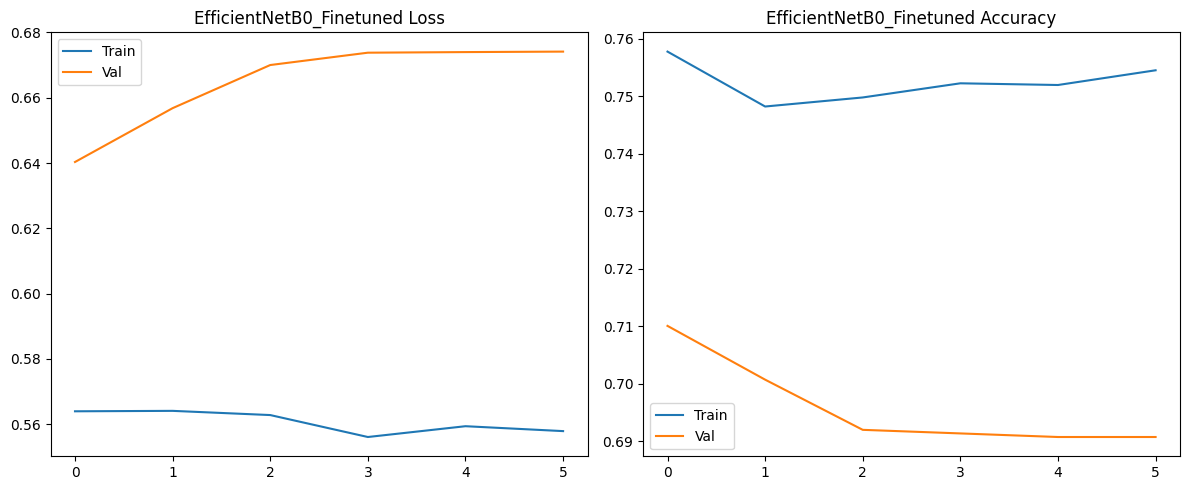

32/32 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step

EFFICIENTNETB0_FINETUNED
              precision    recall  f1-score   support

        high       0.25      0.67      0.36       218
         low       0.95      0.67      0.79      1615
      medium       0.47      0.75      0.58       162

    accuracy                           0.68      1995
   macro avg       0.56      0.70      0.58      1995
weighted avg       0.84      0.68      0.72      1995

Accuracy     : 0.6792
Precision    : 0.8351
Recall       : 0.6792
Weighted F1  : 0.7247
Macro F1     : 0.5756


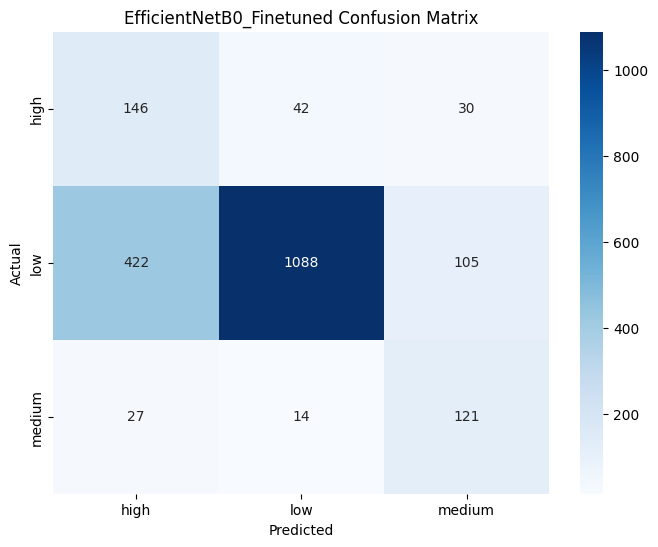

In [90]:
plot_training_history(
    history_b0_ft,
    "EfficientNetB0_Finetuned"
)

results = evaluate_model(
    effb0_model,
    "EfficientNetB0_Finetuned"
)

In [91]:
print(history_b0_ft.history["accuracy"])
print(history_b0_ft.history["val_accuracy"])

print(history_b0_ft.history["loss"])
print(history_b0_ft.history["val_loss"])

[0.7578024864196777, 0.7482524514198303, 0.7498276829719543, 0.7522890567779541, 0.751993715763092, 0.754553496837616]
[0.7100997567176819, 0.7007481455802917, 0.6920199394226074, 0.6913965344429016, 0.690773069858551, 0.690773069858551]
[0.5639662146568298, 0.5640988349914551, 0.5628125667572021, 0.5560911297798157, 0.5593987107276917, 0.5578958988189697]
[0.640322744846344, 0.6568094491958618, 0.6700202226638794, 0.6737991571426392, 0.6739839315414429, 0.6741319298744202]


### MODEL 3 - DenseNet

### MODEL 4 - DenseNet Finetuned

### MODEL 5 - ResNet

## COMPARISON

In [ ]:
model1 = tf.keras.models.load_model(
    "../cv_models/effb0_best.keras"
)

model2 = tf.keras.models.load_model(
    "../cv_models/effb0_finetuned_best.keras"
)


results = []

results.append(
    evaluate_model(model1, "EffB0 Frozen")
)

results.append(
    evaluate_model(model2, "EffB0 Fine Tuned")
)

# results.append(
#     evaluate_model(model3, "ResNet50")
# )

comparison_df = pd.DataFrame(results)

print(
    comparison_df.sort_values(
        "Macro_F1",
        ascending=False
    )
)
